# Ejercicio 1 — Demanda de gas (regresión lineal múltiple)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/blob/main/notebooks/01_demanda_gas_regresion_lineal.ipynb)

**Metodologías de Data Mining — Unidad 3**

Queremos explicar la **demanda diaria de gas** a partir de la temperatura máxima, la temperatura mínima,
el tipo de día (laborable o feriado) y el mes. En este notebook vamos a:

1. Explorar los datos y las correlaciones.
2. Ajustar el modelo `Demanda ~ TempMax + TempMin` por mínimos cuadrados.
3. Evaluar si agregar el tipo de día (y el mes) mejora el modelo.
4. Comparar **todas las combinaciones** de predictores con el $R^2$ ajustado.
5. Revisar los **supuestos** de la regresión lineal.
6. Pronosticar la demanda de un día nuevo.

## 1. Librerías y datos

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

URL_DATOS = "https://raw.githubusercontent.com/fcaceres-create/caece-aprendizaje-artificial-u3-datamining/main/notebooks/datos/"

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def verificar(nombre, obtenido, esperado, decimales=2):
    """Compara un resultado con el valor de referencia de la cátedra (redondeado a `decimales`)."""
    ok = abs(obtenido - esperado) <= 0.5 * 10 ** -decimales + 1e-9
    print(f"{'✔' if ok else '✘'} {nombre}: obtenido = {obtenido:.{decimales}f}   esperado = {esperado}")

In [2]:
df = pd.read_csv(URL_DATOS + "ejercicio1.csv")

# Alternativa: subir el Excel de la cátedra a Colab (ícono de carpeta, a la izquierda) y leer la hoja:
# df = pd.read_excel("EjerciciosRegresion.xlsx", sheet_name="Ejercicio1")

print(df.shape)
df.head()

(62, 5)


,TempMax,TempMin,Mes,Dia,Demanda
0,14.3000,3.6000,Julio,Laborable,1465
1,16.3000,1.2000,Julio,Laborable,1499
2,7.1000,1.2000,Julio,Laborable,1811
3,10.5000,2.0000,Julio,Laborable,1483
4,14.9000,4.3000,Julio,Feriado,1375


Las variables **Dia** y **Mes** son categóricas. Para usarlas en la regresión las convertimos en
**variables ficticias (dummies)** que valen 0 o 1:

- `Laborable` = 1 si el día es laborable, 0 si es feriado.
- `Agosto` = 1 si el día es de agosto, 0 si es de julio.

In [3]:
df["Laborable"] = (df["Dia"] == "Laborable").astype(int)
df["Agosto"] = (df["Mes"] == "Agosto").astype(int)
df.describe()

,TempMax,TempMin,Demanda,Laborable,Agosto
count,62.0000,62.0000,62.0000,62.0000,62.0000
mean,13.4548,3.7855,"1,504.4516",0.6935,0.5000
std,3.3601,3.0716,178.8040,0.4648,0.5041
min,7.1000,-4.2000,"1,120.0000",0.0000,0.0000
25%,10.6000,1.6000,"1,376.0000",0.0000,0.0000
50%,13.2500,2.7500,"1,514.5000",1.0000,0.5000
75%,15.4000,6.3500,"1,619.7500",1.0000,1.0000
max,21.6000,9.9000,"2,013.0000",1.0000,1.0000


## 2. Exploración: correlaciones y gráficos de dispersión

In [4]:
df[["TempMax", "TempMin", "Laborable", "Agosto", "Demanda"]].corr()

,TempMax,TempMin,Laborable,Agosto,Demanda
TempMax,1.0000,0.1401,-0.0583,-0.0484,-0.7405
TempMin,0.1401,1.0000,-0.0135,-0.2260,-0.6793
Laborable,-0.0583,-0.0135,1.0000,-0.0350,0.0254
Agosto,-0.0484,-0.2260,-0.0350,1.0000,0.2590
Demanda,-0.7405,-0.6793,0.0254,0.2590,1.0000


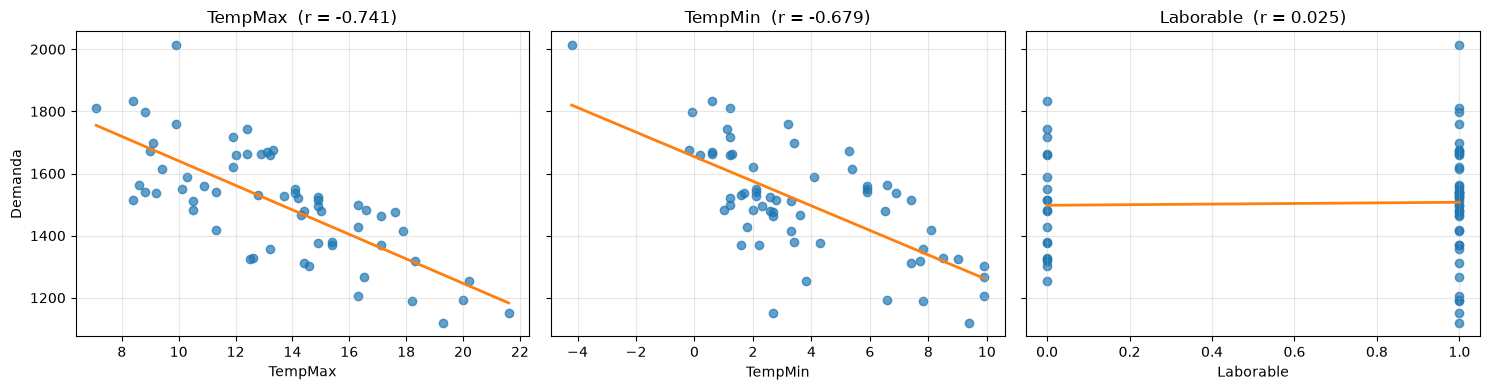

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, x in zip(axes, ["TempMax", "TempMin", "Laborable"]):
    ax.scatter(df[x], df["Demanda"], alpha=0.7)
    b1, b0 = np.polyfit(df[x], df["Demanda"], 1)
    xs = np.linspace(df[x].min(), df[x].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color="tab:orange", linewidth=2)
    ax.set_title(f"{x}  (r = {df[x].corr(df['Demanda']):.3f})")
    ax.set_xlabel(x)
axes[0].set_ylabel("Demanda")
plt.tight_layout()
plt.show()

Las dos temperaturas tienen una correlación **negativa** fuerte con la demanda: cuanto más calor,
menos gas se consume. El tipo de día, en cambio, casi no se relaciona con la demanda.

## 3. Modelo `Demanda ~ TempMax + TempMin`

In [6]:
modelo = smf.ols("Demanda ~ TempMax + TempMin", data=df).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                Demanda   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     229.9
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.41e-28
Time:                        09:36:30   Log-Likelihood:                -341.63
No. Observations:                  62   AIC:                             689.3
Df Residuals:                      59   BIC:                             695.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2105.1235     32.820     64.141      0.0

In [7]:
b = modelo.params
print(f"Demanda = {b['Intercept']:.2f} {b['TempMax']:+.2f}·TempMax {b['TempMin']:+.2f}·TempMin\n")

verificar("Constante", b["Intercept"], 2105.12)
verificar("Coeficiente TempMax", b["TempMax"], -35.03)
verificar("Coeficiente TempMin", b["TempMin"], -34.17)
verificar("R²", modelo.rsquared, 0.886, 3)
verificar("R² ajustado", modelo.rsquared_adj, 0.882, 3)
verificar("F", modelo.fvalue, 229.9, 1)

Demanda = 2105.12 -35.03·TempMax -34.17·TempMin

✔ Constante: obtenido = 2105.12   esperado = 2105.12
✔ Coeficiente TempMax: obtenido = -35.03   esperado = -35.03
✔ Coeficiente TempMin: obtenido = -34.17   esperado = -34.17
✔ R²: obtenido = 0.886   esperado = 0.886
✔ R² ajustado: obtenido = 0.882   esperado = 0.882
✔ F: obtenido = 229.9   esperado = 229.9


**Interpretación**

- Con la temperatura mínima fija, cada grado adicional de máxima **reduce** la demanda en unas 35 unidades.
- Con la máxima fija, cada grado adicional de mínima la reduce en unas 34 unidades.
- El modelo explica el **88,6 %** de la variabilidad de la demanda ($R^2 = 0{,}886$).
- El test F tiene un p-valor prácticamente nulo: el modelo en conjunto es significativo.

Otras medidas de error (el MSE se calcula como $SC_{res}/n$):

In [8]:
n = int(modelo.nobs)
pd.Series({
    "Error estándar de la estimación": np.sqrt(modelo.mse_resid),
    "MSE": modelo.ssr / n,
    "RMSE": np.sqrt(modelo.ssr / n),
    "MAE": modelo.resid.abs().mean(),
    "p-valor del modelo (F)": modelo.f_pvalue,
})

Error estándar de la estimación      61.3146
MSE                               3,577.5698
RMSE                                 59.8128
MAE                                  45.3162
p-valor del modelo (F)                0.0000
dtype: float64

## 4. ¿Conviene agregar el tipo de día?

In [9]:
modelo_lab = smf.ols("Demanda ~ TempMax + TempMin + Laborable", data=df).fit()
print(modelo_lab.summary().tables[1])

verificar("Coeficiente Laborable", modelo_lab.params["Laborable"], -8.09)
verificar("p-valor Laborable", modelo_lab.pvalues["Laborable"], 0.636, 3)
print(f"\nR² ajustado sin Laborable: {modelo.rsquared_adj:.4f}   con Laborable: {modelo_lab.rsquared_adj:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2111.6298     35.762     59.047      0.000    2040.044    2183.215
TempMax      -35.0933      2.379    -14.750      0.000     -39.856     -30.331
TempMin      -34.1804      2.598    -13.154      0.000     -39.382     -28.979
Laborable     -8.0941     17.032     -0.475      0.636     -42.187      25.999


✔ Coeficiente Laborable: obtenido = -8.09   esperado = -8.09
✔ p-valor Laborable: obtenido = 0.636   esperado = 0.636

R² ajustado sin Laborable: 0.8824   con Laborable: 0.8808


El coeficiente de `Laborable` **no es significativo** (p = 0,636 > 0,05) y el $R^2$ ajustado **baja**:
agregar el tipo de día no mejora el modelo.

## 5. Comparación de todas las combinaciones de predictores

Probamos los $2^4 - 1 = 15$ modelos posibles con TempMax, TempMin, Laborable y Agosto, y los ordenamos
por $R^2$ ajustado, que penaliza la cantidad de variables.

In [10]:
candidatos = ["TempMax", "TempMin", "Laborable", "Agosto"]
filas = []
for k in range(1, len(candidatos) + 1):
    for combo in itertools.combinations(candidatos, k):
        m = smf.ols("Demanda ~ " + " + ".join(combo), data=df).fit()
        no_sig = [f"{v} (p={m.pvalues[v]:.3f})" for v in combo if m.pvalues[v] >= 0.05]
        filas.append({
            "Predictores": " + ".join(combo),
            "k": k,
            "R²": m.rsquared,
            "R² ajustado": m.rsquared_adj,
            "Error est.": np.sqrt(m.mse_resid),
            "F": m.fvalue,
            "p (F)": m.f_pvalue,
            "No significativos": ", ".join(no_sig) or "—",
        })

comparacion = pd.DataFrame(filas).sort_values("R² ajustado", ascending=False).reset_index(drop=True)
comparacion.index += 1
print("Mejor modelo:", comparacion.loc[1, "Predictores"])
comparacion

Mejor modelo: TempMax + TempMin + Agosto


,Predictores,k,R²,R² ajustado,Error est.,F,p (F),No significativos
1,TempMax + TempMin + Agosto,3,0.8957,0.8903,59.2296,165.9708,0.0000,—
2,TempMax + TempMin + Laborable + Agosto,4,0.8960,0.8887,59.6629,122.7171,0.0000,Laborable (p=0.690)
3,TempMax + TempMin,2,0.8863,0.8824,61.3146,229.8741,0.0000,—
4,TempMax + TempMin + Laborable,3,0.8867,0.8808,61.7209,151.3138,0.0000,Laborable (p=0.636)
5,TempMax + Agosto,2,0.5983,0.5847,115.2299,43.9386,0.0000,—
6,TempMax + Laborable + Agosto,3,0.5984,0.5776,116.2062,28.8065,0.0000,Laborable (p=0.910)
7,TempMax,1,0.5484,0.5409,121.1577,72.8563,0.0000,—
8,TempMax + Laborable,2,0.5487,0.5334,122.1369,35.8673,0.0000,Laborable (p=0.839)
9,TempMin + Agosto,2,0.4732,0.4553,131.9624,26.4956,0.0000,Agosto (p=0.257)
10,TempMin,1,0.4615,0.4525,132.3054,51.4113,0.0000,—


**Lectura de la tabla**

- Con los predictores del enunciado (TempMax, TempMin y Laborable), el mejor modelo es **TempMax + TempMin**
  ($R^2$ ajustado = 0,882). Agregar `Laborable` nunca ayuda: no es significativa en ningún modelo.
- Si además se considera el **mes**, el primer puesto pasa a **TempMax + TempMin + Agosto**
  ($R^2$ ajustado = 0,890) y `Agosto` **sí** es significativa (p ≈ 0,026): a igual temperatura, en agosto
  se consumen unas 35 unidades más. La mejora es chica y tiene sentido práctico preguntarse si conviene
  incluir una variable que solo vale para estos dos meses: con datos de un único invierno, no sabemos si
  ese efecto se repetiría en otro año.

Por eso el modelo de referencia del ejercicio es **TempMax + TempMin**, pero vale la pena discutir el mes.

In [11]:
modelo_mes = smf.ols("Demanda ~ TempMax + TempMin + Agosto", data=df).fit()
print(modelo_mes.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2081.3442     33.367     62.378      0.000    2014.553    2148.135
TempMax      -34.9385      2.280    -15.325      0.000     -39.502     -30.375
TempMin      -32.8776      2.557    -12.857      0.000     -37.996     -27.759
Agosto        35.3142     15.446      2.286      0.026       4.395      66.234


## 6. Supuestos de la regresión lineal

| Supuesto | Cómo se revisa |
|---|---|
| Linealidad | Gráfico de residuos vs. estimado y test RESET de Ramsey |
| Normalidad de los residuos | Histograma, gráfico Q-Q y test de Shapiro-Wilk (y Jarque-Bera) |
| Homocedasticidad | Gráfico de residuos vs. estimado y test de Breusch-Pagan |
| No multicolinealidad | VIF (factor de inflación de la varianza) |

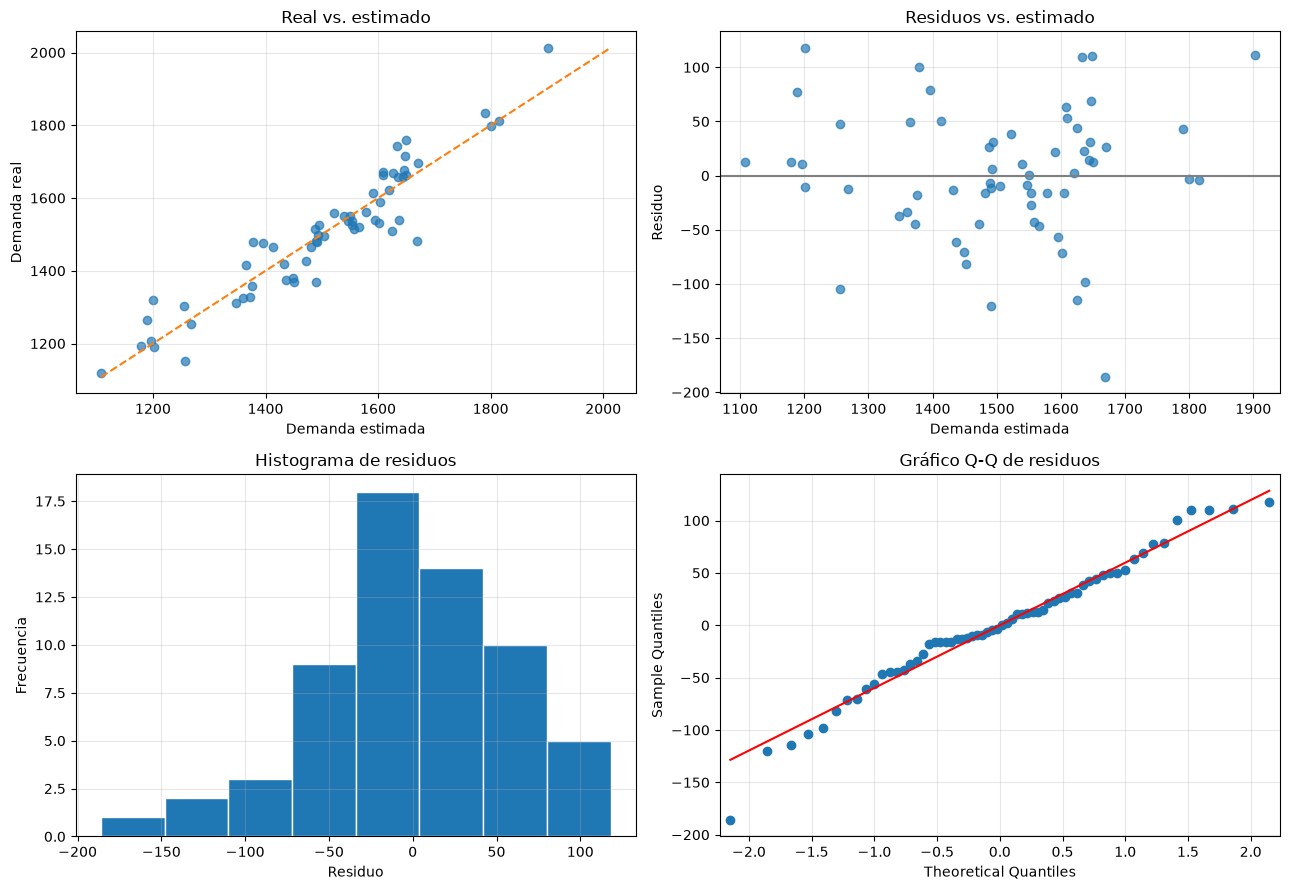

In [12]:
estimado = modelo.fittedvalues
residuos = modelo.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.scatter(estimado, df["Demanda"], alpha=0.7)
lim = [min(estimado.min(), df["Demanda"].min()), max(estimado.max(), df["Demanda"].max())]
ax.plot(lim, lim, "--", color="tab:orange")
ax.set(title="Real vs. estimado", xlabel="Demanda estimada", ylabel="Demanda real")

ax = axes[0, 1]
ax.scatter(estimado, residuos, alpha=0.7)
ax.axhline(0, color="gray")
ax.set(title="Residuos vs. estimado", xlabel="Demanda estimada", ylabel="Residuo")

ax = axes[1, 0]
ax.hist(residuos, bins=8, edgecolor="white")
ax.set(title="Histograma de residuos", xlabel="Residuo", ylabel="Frecuencia")

sm.qqplot(residuos, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Gráfico Q-Q de residuos")

plt.tight_layout()
plt.show()

In [13]:
def semaforo(p):
    return "🟢 se cumple" if p >= 0.05 else ("🟡 dudoso" if p >= 0.01 else "🔴 no se cumple")


X = modelo.model.exog
vif = pd.Series(
    [variance_inflation_factor(X, i) for i in range(1, X.shape[1])],
    index=modelo.model.exog_names[1:],
    name="VIF",
)

sw = stats.shapiro(residuos)
jb = stats.jarque_bera(residuos)
bp_lm, bp_p, _, _ = het_breuschpagan(residuos, X)
reset = linear_reset(modelo, power=3, use_f=True)

supuestos = pd.DataFrame([
    ["Linealidad", "RESET de Ramsey (F)", reset.fvalue, reset.pvalue, semaforo(reset.pvalue)],
    ["Normalidad", "Shapiro-Wilk (W)", sw.statistic, sw.pvalue, semaforo(sw.pvalue)],
    ["Normalidad", "Jarque-Bera", jb.statistic, jb.pvalue, semaforo(jb.pvalue)],
    ["Homocedasticidad", "Breusch-Pagan (LM)", bp_lm, bp_p, semaforo(bp_p)],
    ["No multicolinealidad", "VIF máximo", vif.max(), np.nan, "🟢 se cumple" if vif.max() < 5 else "🔴 revisar"],
], columns=["Supuesto", "Test", "Estadístico", "p-valor", "Veredicto"])
print(vif, "\n")
supuestos

TempMax   1.0200
TempMin   1.0200
Name: VIF, dtype: float64 



,Supuesto,Test,Estadístico,p-valor,Veredicto
0,Linealidad,RESET de Ramsey (F),2.4443,0.0958,🟢 se cumple
1,Normalidad,Shapiro-Wilk (W),0.9778,0.3225,🟢 se cumple
2,Normalidad,Jarque-Bera,2.1817,0.3359,🟢 se cumple
3,Homocedasticidad,Breusch-Pagan (LM),1.4415,0.4864,🟢 se cumple
4,No multicolinealidad,VIF máximo,1.0200,NaN,🟢 se cumple


Semáforo: 🟢 si p ≥ 0,05 (no hay evidencia contra el supuesto), 🟡 si 0,01 ≤ p < 0,05 y 🔴 si p < 0,01.
Para el VIF: menor a 5 es aceptable.

Con este modelo se cumplen todos los supuestos.

## 7. Pronóstico para un día nuevo

In [14]:
nuevo = pd.DataFrame({"TempMax": [12.0], "TempMin": [3.0]})
pronostico = modelo.get_prediction(nuevo).summary_frame(alpha=0.05)
p = pronostico.iloc[0]
print(f"Demanda pronosticada: {p['mean']:.1f}")
print(f"Intervalo de predicción 95 %: {p['obs_ci_lower']:.1f} a {p['obs_ci_upper']:.1f}")
pronostico

Demanda pronosticada: 1582.3
Intervalo de predicción 95 %: 1458.4 a 1706.2


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,"1,582.2559",8.6361,"1,564.9751","1,599.5367","1,458.3547","1,706.1571"


## Conclusiones

- El modelo elegido es **Demanda = 2105,12 − 35,03·TempMax − 34,17·TempMin**, con $R^2 = 0{,}886$.
- El tipo de día no aporta información significativa una vez consideradas las temperaturas.
- El mes (agosto) mejora levemente el ajuste ($R^2$ ajustado 0,890) y es significativo, aunque con un solo
  invierno de datos es difícil saber si ese efecto se generaliza.
- Los residuos cumplen los supuestos de linealidad, normalidad y homocedasticidad, y no hay multicolinealidad.

👉 Para jugar con los datos en tiempo real, usá la web interactiva (pestaña **1. Demanda de gas**).